# `kNNpy.kNN_2D_Ang` Tutorial: Clustering in the sky using 2D $k$-nearest neighbour distributions

# Part 3: Tracer-tracer cross-clustering

**Author**: Kaustubh Rajesh Gupta (email:[kaustubhrajeshgupta@swin.edu.au](mailto:kaustubhrajeshgupta@swin.edu.au))
\
**Date**: 13 July 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `kNNpy.kNN_2D_Ang` module to compute the 2D tracer-tracer cross $k$NN distributions in angular coordinates for given data and interpret the results. The basic functionalities of the module are illustrated using realistic cosmological data. A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/kNN_2D_Ang.html) and source code for the module is available on the `kNNpy` [website](https://kitnenikatnivasi.github.io/).

<!--TABLE OF CONTENTS-->
## Contents:

- [Imports and setup](#Imports-and-setup)
- [Motivation for tracer-tracer crosss-correlations](#mot)
- [Load and visualize mock cluster and galaxy data](#mock)
- [Compute the relevant spatial scales and construct query points](#scale)
- [Compute and plot the nearest-neighbour distributions](#cdf)
- [Interpretation of the CDFs](#int)
- [Excess cross-correlation](#psi)
- [Thinking challenge](#think_ch)
- [Computational challenge 1](#comp_ch)
- [Computational challenge 2](#comp_ch_1)

## Imports and setup

#### Let's start by importing the required Python libraries. These should already be present in the `kNNpy_env` virtual environment created during the [installation](https://kitnenikatnivasi.github.io/install.html), so you should be able to import them without any issues.

In [1]:
#Importing external libraries

import numpy as np

import healpy as hp
from healpy.newvisufunc import projview

from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors

import copy

import os
import sys

import warnings

#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('../'))           # '../' is needed because the parent directory is one directories upstream of the tutorials directory
if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf                 #some helper functions
from kNNpy import HelperFunctions_2DA as hf_2DA         #2D specifi helper functions
from kNNpy import kNN_2D_Ang                            #the main module
from kNNpy.Data import Datasets                         #helpful for retreiving example datasets

#### We define our `matplotlib` plotting preferences below; you can change them to your liking. Remember to set `ustex==False` if you do not have $\LaTeX$ installed. 

In [2]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 18})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']

## Main

#### <a name="mot" id="mot"></a> Motivation: an example where tracer-tracer cross-correlations are important to study

Let's say we are interested in studying the clustering properties of galaxy clusters. One possible approach is to compute their auto-clustering, following the method outlined in tutorial part 1. However, auto-clustering measurements for discrete tracers suffer from Poisson noise (aka shot noise) that arises due to finite number statistics. This possion noise is inversely proportional to the number density of tracers. This becomes a problem for rare objects such as galaxy clusters, where the shot noise can dominate over the clustering signal, making it hard to detect even using higher order statistics. 

A solution to this problem is to cross-correlate these rare tracers with a continuous field that is expected to be correlated with them, such as the matter density field, following the method outlined in tutorial part 2. Cross correlations do not suffer from shot noise, since the shot noise in the two different data sets is usually uncorrelated and cancels out during the cross-correlation. Although this solves the problem of shot noise, matter density fields are difficult to directly measure, usually very noisy, and often not available in the spatial regions or scales of interest.

A different approach is to cross-correlate the rare tracers with a different set of tracers that are expected to be spatially correlated. For example, galaxies and galaxy clusters are expected to be correlated with each other, since both trace a common underlying matter density field, albeit with different biases. This approach combines the advantage of cross-correlations with the ready availability of data from large galaxy surveys.

#### In this tutorial, we illustrate how to use `kNNpy` to quantify 2D tracer-tracer cross-correlations with the $k$-nearest neighbour distributions. For this purpose, we use samples of cluster and galaxy-scale dark matter haloes from the publicly available [Quijote simulations](https://quijote-simulations.readthedocs.io/en/latest/) as proxies for clusters and galaxies, respectively. The underlying data used to create these samples is the same as the one we used in tutorial 1.

#### <a name="mock" id="mock"></a> Let's create the mock data using the `kNNpy.Data.Datasets` module, including a set of randoms to serve as the control.

Before we do that, we need to discuss an import aspect of tracer-tracer cross-correlations using the nearest-neighbour distributions. As discussed in an earlier tutorial, the nearest-neighbour measurements are highly sensitive to number density of the tracers. This means that in order to faithfully capture the cross-correlation between two sets of tracers, their number densities need to be comparable to each other (see [Banerjee & Abel (2021)](https://academic.oup.com/mnras/article/504/2/2911/6246418?login=false) for a discussion). As you will investigate in the thinking and computational challenges later in the tutorial, cross-correlating tracers with different vastly different number densities using nearest-neighbour measurements is challenging. Therefore, for the sake of demonstration, we set the number densities of the two tracers to be equal by hand. This is of course an artificial choice, since two different sets of tracers can have vastly different observed number densities. We will explore a more realistic approach in the upcoming challenges.

In [4]:
#Defining the galaxy sample

NSIDE = 256                 #determines the HEALpix angular resolution for the calculations
n_reals = 10                #the number of realisations for the cluster-scale haloes (first tracer) sampled from the box 
n_cl = 2_000                #the number of cluster-scale haloes in each realisaton
n_ga = 2_000                #the number of galaxy-scale haloes (second tracer); we use just one realisations of the galaxy sample for simplicity
sim_num = 0                 #the quijote box number used. Currently, only simulation box 0 comes pre-loaded with kNNpy
mask = np.ones(12*NSIDE**2) #the observational footprint; for this example, let's set it to the entire sky
mask[mask!=1] = hp.UNSEEN

In [ ]:
#Creating cluster and galaxy catalogues from the quijote box using the kNNpy.Data.Datasets module; only one realisation is needed for the galaxies. If you want reproducible results, you can fix the seed used to generate the random sample by providing a value to the seed parameter
cl_pos_masked_ds_arr, cl_map = Datasets.Sample2DTracersFromQuijoteBox(sim_num=sim_num, tracer_type='Clusters', mask=mask, N_realisations=n_reals, n_tracers=n_tracer, seed=None, map_NSIDE=64, DataPath='../kNNpy/Data')
ga_pos_masked_ds_arr, ga_map = Datasets.Sample2DTracersFromQuijoteBox(sim_num=sim_num, tracer_type='Galaxies', mask=mask, N_realisations=1, n_tracers=n_tracer, seed=None, map_NSIDE=64, DataPath='../kNNpy/Data')
ga_pos_masked_ds = ga_pos_masked_ds_arr[0]

#Creating the same number of realisations of randoms on the sky as clusters to serve as the control
randoms_pos_masked_ds_arr, randoms_map = Datasets.Sample2DPoissonTracers(mask=mask, N_realisations=n_reals, n_tracers=n_tracer, seed=None, map_NSIDE=64)

In [3]:
#Defining the galaxy sample

NSIDE = 256                 #determines the HEALpix angular resolution for the calculations
n_reals = 10                #the number of realisations of cluster-scale haloes (first set of discrete tracers)
n_cl = 2000                 #the number of cluster-scale haloes in each realisation
n_ga = 2000                 #the number of galaxy-scale haloes (second set of discrete tracers); we use a single realisation for simplicity
sim_num = 0                 #the quijote box number used. Currently, only simulation box 0 comes pre-loaded with kNNpy
mask = np.ones(12*NSIDE**2) #the observational footprint; for this example, let's set it to the entire sky
mask[mask!=1] = hp.UNSEEN

In [4]:
#Creating mock cluster and galaxy catalogues from the quijote box. If you want reproducible results, you can fix the seed used to generate the random sample by providing a value to the seed parameter
cl_pos_masked_ds_arr, cl_map = Datasets.Sample2DTracersFromQuijoteBox(sim_num=sim_num, tracer_type='Clusters', mask=mask, N_realisations=n_reals, n_tracers=n_cl, seed=None, map_NSIDE=64)
ga_pos_masked_ds_arr, ga_map = Datasets.Sample2DTracersFromQuijoteBox(sim_num=sim_num, tracer_type='Galaxies', mask=mask, N_realisations=1, n_tracers=n_ga, seed=None, map_NSIDE=64)
ga_pos_masked_ds = ga_pos_masked_ds_arr[0]

#Creating the same number of realisations of randoms on the sky as clusters to serve as the control
randoms_pos_masked_ds_arr, randoms_map = Datasets.Sample2DPoissonTracers(mask=mask, N_realisations=n_reals, n_tracers=n_cl, seed=None, map_NSIDE=64)

#### Let's vizualize how the mock data is distributed in the sky

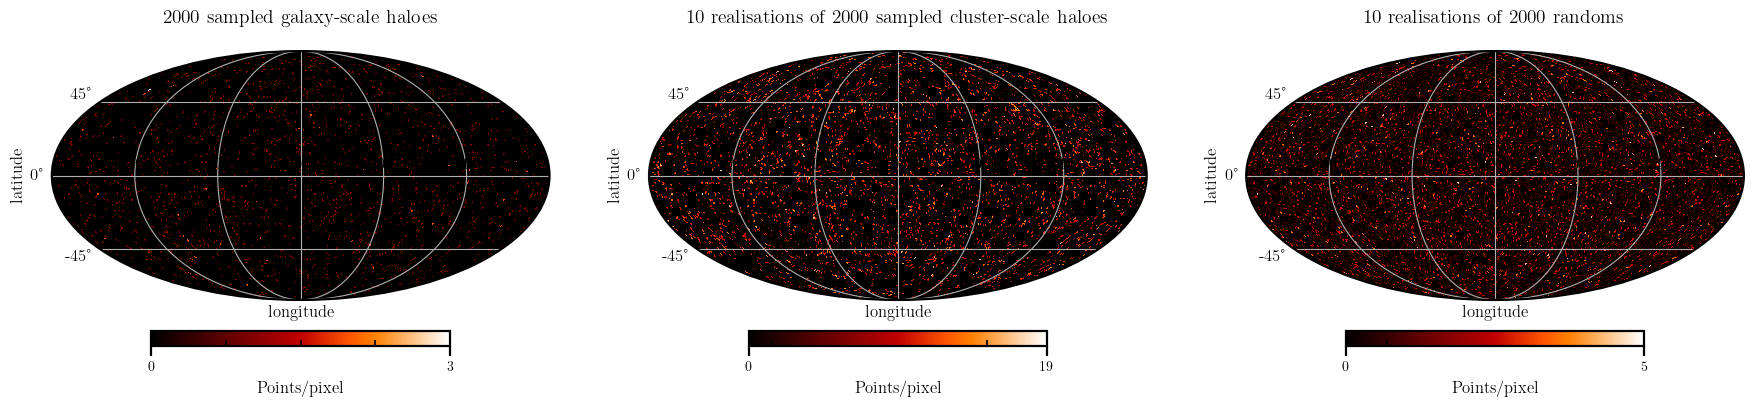

In [10]:
fig = plt.figure(figsize=(18, 7))
ax1, ax2, ax3 = plt.subplot(1, 3, 1), plt.subplot(1, 3, 2), plt.subplot(1, 3, 3)

plt.axes(ax1)
projview(
    ga_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_ga} sampled galaxy-scale haloes\n",
    norm="linear", 
    flip="astro",
    cmap='gist_heat',
    # min=map_gal[mask!=hp.UNSEEN].min(),
    # max=map_gal[mask!=hp.UNSEEN].max(),
    hold=True,
    sub=131
)

plt.axes(ax2)
projview(
    cl_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_reals} realisations of {n_cl} sampled cluster-scale haloes\n",
    norm="symlog", 
    flip="astro",
    cmap='gist_heat',
    # min=map_gal[mask!=hp.UNSEEN].min(),
    # max=map_gal[mask!=hp.UNSEEN].max(),
    hold=True,
    sub=132
)

plt.axes(ax3)
projview(
    randoms_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_reals} realisations of {n_cl} randoms\n",
    norm="symlog", 
    flip="astro",
    cmap='gist_heat',
    # min=map_1[mask!=hp.UNSEEN].min(),
    # max=map_1[mask!=hp.UNSEEN].max(),
    hold=True,
    sub=133
)

plt.show()
plt.close()

#### <a name="scale" id="scale"></a> Let us compute the (1,1), (2,2) and (4,4)NN cross-correlations (ie., correlations using the same order nearest-neighbour for the the two tracers) for simplicity. We will explore cross-correlations using different nearest neighbour orders for the two tracers in an upcoming computational challenge. 

#### As in the previous tutorials, the first step is to compute the relevant spatial scales of interest at which the $k$NN distributions can be computed. This is dictated by the number density of the cluster-scale haloes, and is computed in a similar way as the previous tutorials.

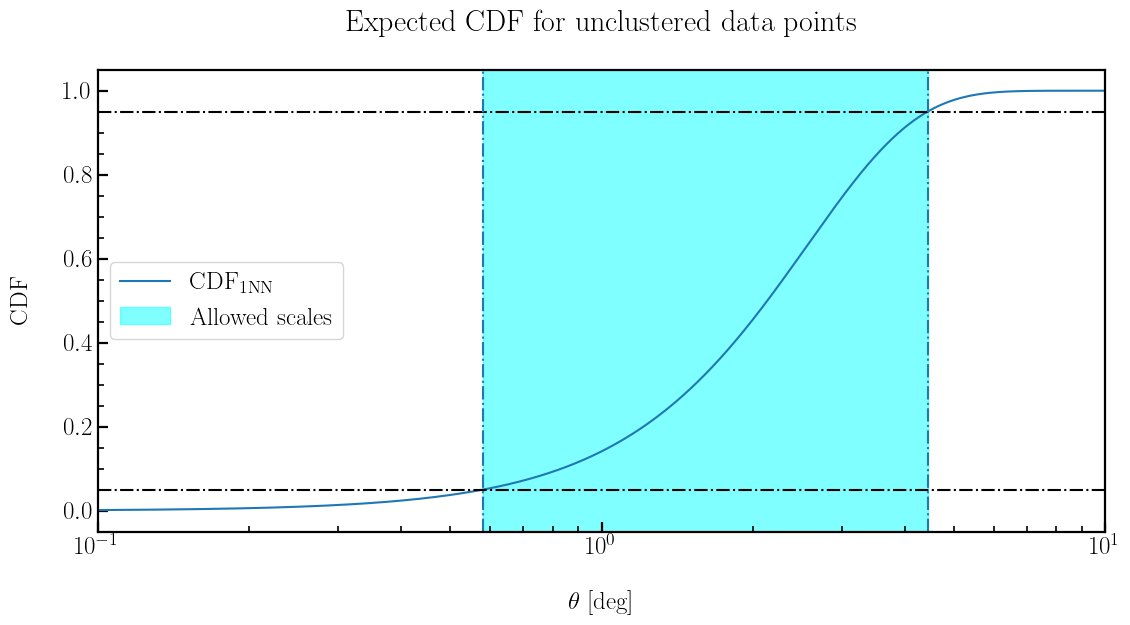

Relevant angular distance scales (deg):

	1NN:	 0.58 4.44
	2NN:	 1.53 5.59
	4NN:	 3.00 7.14


In [15]:
#Defining which neighbours to use
kA_kB_List = [(1,1), (2,2), (4,4)]
k_List = [1, 2, 4]

#Getting the tracer number density
n_bar_red = (cl_pos_masked_ds_arr.shape[1]/(4*np.pi))*(12*NSIDE**2/len(np.where(mask!=hp.UNSEEN)[0]))

#Computing the analytical value of the kNN-CDFs for unclustered data on a wide range of angular scales

bins = np.zeros((len(k_List), 10000))
for i, k in enumerate(k_List):
    bins[i] = np.deg2rad(np.geomspace(0.001, 12, 10000))

Theoretical_Uniform_CDFs_test = []
for i, k in enumerate(k_List):
    Theoretical_Uniform_CDFs_test.append(hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(bins[i])), n_bar_red, k))

#Selecting 10 log-spaced bins where the kNN-CDFs are expected to be between 0.05 and 0.95

low_bin = np.zeros(len(k_List)).astype(int)
high_bin = np.zeros(len(k_List)).astype(int)

for i, k in enumerate(k_List):
    low_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.05)
    high_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.95)

sel_bins = np.zeros((len(k_List), 10))
for i, k in enumerate(k_List):
    sel_bins[i] = np.geomspace(bins[i][low_bin[i]]*0.95, bins[i][high_bin[i]]*1.05, 10)

th_uni_arr = np.zeros((len(k_List), sel_bins.shape[1]))
for i, k in enumerate(k_List):
    th_uni_arr[i] = hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(sel_bins[i])), n_bar_red, k)

#Let's plot the expected 1NN-CDF for the unclustered data
plt.figure(figsize=(13,6))
i=0    #change the value of i and k to plot a different kNN-CDF
k=1
plt.plot(np.rad2deg(bins[i]), Theoretical_Uniform_CDFs_test[i], label='CDF$_{{\\rm {}NN}}$'.format(k))
plt.axhline(0.05, ls='-.', c='k')
plt.axhline(0.95, ls='-.', c='k')
plt.axvline(np.rad2deg(bins[i][low_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvline(np.rad2deg(bins[i][high_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvspan(np.rad2deg(bins[i][low_bin[i]]), np.rad2deg(bins[i][high_bin[i]]), alpha=0.5, color=BrightColors[i], label=f'Allowed scales')
plt.xlim([0.1, 10])
plt.title('Expected CDF for unclustered data points\n')
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('CDF\n')
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()
plt.close()

#Print out the scales
print('Relevant angular distance scales (deg):\n')
for i, k in enumerate(k_List):
    print(f'\t{k}NN:\t', '{:.2f}'.format(np.rad2deg(bins[i][low_bin[i]])), '{:.2f}'.format(np.rad2deg(bins[i][high_bin[i]])))
# Uncomment lines below to print out the exact scales sampled
# for i, k in enumerate(k_List):
#     print(f'\nAngular distance bins for {k}NN-CDF: \n\n', np.rad2deg(sel_bins[i]))
#     print(f'\nNumber of bins for {k}NN-CDF: ', len(sel_bins[i]))

#### The next step is to construct the query points from which the nearest-neighbour distances are to be computed:

In [16]:
#Generate the query positions
query_mask, query_pos = hf_2DA.create_query_2DA(NSIDE, mask)

#### <a name="cdf" id="cdf"></a> Now, we are ready to measure the cluster-galaxy cross-clustering for our mock datasets. Let's use the `TracerTracerCross2DA_DataVector()` method to compute the nearest-neighbour distributions for the multiple realisations of the mock clusters and the randoms. 

**Note:** for a single realisation of the tracers, you can use the `TracerTracerCross2DA()` method.

#### The quantities being computed are:
1. the auto-CDFs for the discrete tracers $\mathcal{P}_{\geq k_{\rm cl}}^{\rm cl}$, $\mathcal{P}_{\geq k_{\rm ga}}^{\rm ga}$
2. the cluster-galaxy cross-CDFs $\mathcal{P}_{\geq k_{\rm cl}, \geq k_{\rm ga}}^{\rm cl, ga}$,

#### as defined in 3D by [Banerjee & Abel (2021)](https://academic.oup.com/mnras/article/504/2/2911/6246418?login=false) and generalized to 2D angular coordinates here.

**Caution:** since we are running 20 realisations (10 clusters + 10 randoms), this calculation will take some time to complete (approximately 1-2 minutes). If you want quicker results, reduce the number of realisations by chaning the ``n_reals`` parameter, although that will reduce the quality of the results.

In [18]:
#Print the API documentation for details on the function usage
help(kNN_2D_Ang.TracerTracerCross2DA_DataVector)

Help on function TracerTracerCross2DA_DataVector in module kNNpy.kNN_2D_Ang:

TracerTracerCross2DA_DataVector(kA_kB_list, BinsRad, MaskedQueryPosRad, MaskedTracerPosVectorRad_A, MaskedTracerPosRad_B, Verbose=False)
    Returns 'data vectors' of the probabilities $P_{\geq k_A}$, $P_{\geq k_B}$ and $P_{\geq k_A, \geq k_B}$ [refer to kNNpy.kNN_2D_Ang.TracerTracerCross2DA for definitions] for ($k_A$, $k_B$) in `kA_kB_list` for multiple realisations of discrete tracer A [`MaskedTracerPosVectorRad_A`] and a single realisation of the discrete tracer `MaskedTracerPosRad_B`. Please refer to notes to understand why this might be useful.

    Parameters
    ----------
    kA_kB_list : list of int tuples
        nearest-neighbour combinations for which the cross-correlations need to be computed (see notes for more details)
    BinsRad : list of numpy float array
        list of angular distance scale arrays (in radians) for each nearest neighbour combination in `kA_kB_list`. The $i^{th}$ element o

In [21]:
# Let's create a combined list of the independent realisations of the randoms and the mock BBHs. This is just so we can get the results using a single call to the function, but you can compute the results separately if you want.

combined_pos_masked_ds_arr = np.concatenate([randoms_pos_masked_ds_arr, cl_pos_masked_ds_arr], axis=0)


In [23]:
#Computing the nearest-neighbour distributions

clusterxgalaxy_kNN_results_DataVector = kNN_2D_Ang.TracerTracerCross2DA_DataVector(kA_kB_List, sel_bins, query_pos, combined_pos_masked_ds_arr, ga_pos_masked_ds, Verbose=True)

Checking inputs ...
	done.


First carrying out nearest-neighbour computations for tracer B


building the tree...
	time taken: 1.20e-03 s.

computing the NN distances...
	done; time taken: 1.93e+00 s.

computing the auto-CDFs P_{>=kB} ...
	done; time taken: 1.50e-01 s.


Now looping over the realisations of tracer A



--------------  Realisation 1/20  --------------


building the trees ...
	done; time taken: 3.09e-04 s.

computing the NN distances ...
	done; time taken: 1.92e+00 s.

computing the auto-CDFs P_{>=kA} ...
	done; time taken: 1.48e-01 s.

computing the joint-CDFs P_{>=kA, >=kB} ...
	done; time taken: 1.59e-01 s.

time taken for realisation 1: 2.23e+00 s.


--------------  Realisation 2/20  --------------


building the trees ...
	done; time taken: 3.23e-04 s.

computing the NN distances ...
	done; time taken: 1.92e+00 s.

computing the auto-CDFs P_{>=kA} ...
	done; time taken: 1.53e-01 s.

computing the joint-CDFs P_{>=kA, >=kB} ...
	done; time taken: 1.68e-01 s.

time t

In [25]:
#Let's get the component nearest-neighbour distributions

autoCDFs = clusterxgalaxy_kNN_results_DataVector[0]
galAutoCDFs = clusterxgalaxy_kNN_results_DataVector[1]
jointCDFs = clusterxgalaxy_kNN_results_DataVector[2]

#### Let's plot the average of the nearest-neighbour distributions across the realisations

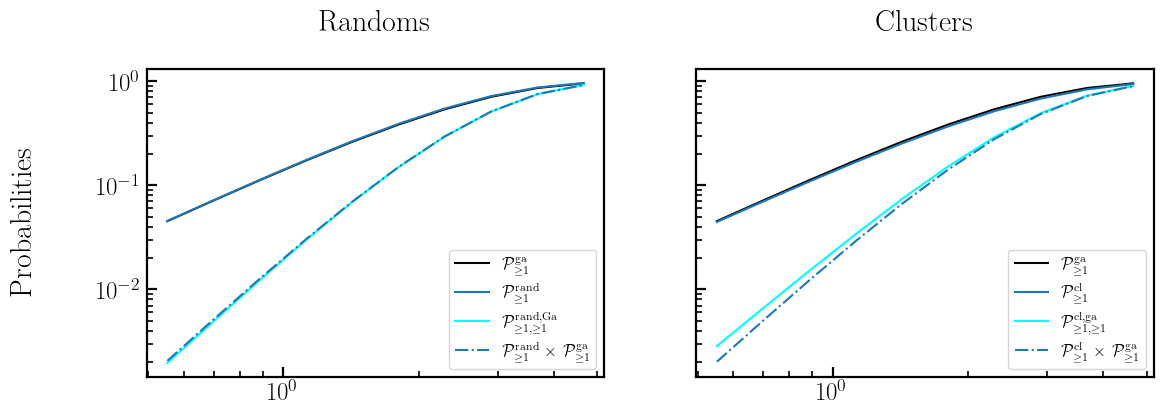

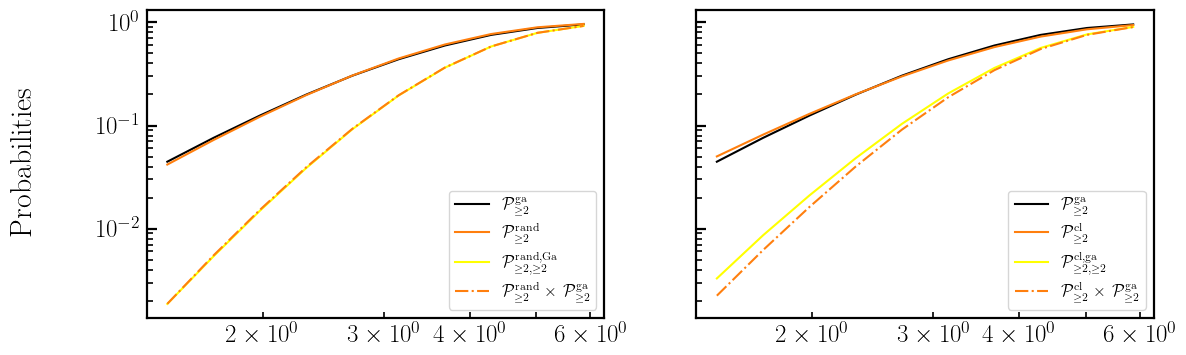

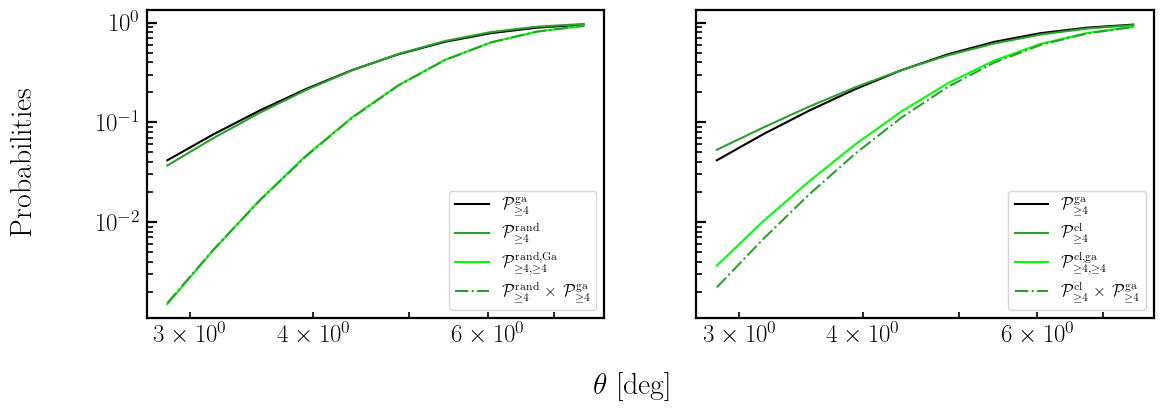

In [33]:
for i, (kA, kB) in enumerate(kA_kB_List):

    fig, (ax, ax1) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    
    ax.plot(np.rad2deg(sel_bins[i]), galAutoCDFs[i], c='k', ls='solid', label='$\\mathcal{{P}}^{{\\rm ga}}_{{\\geq {:.0f}}}$'.format(kB))
    ax.plot(np.rad2deg(sel_bins[i]), np.mean(autoCDFs[i][:n_reals], axis=0), c=DefaultColorCycle[i], label='$\\mathcal{{P}}^{{\\rm rand}}_{{\\geq {:.0f}}}$'.format(kA))
    ax.plot(np.rad2deg(sel_bins[i]), np.mean(jointCDFs[i][:n_reals], axis=0), c=BrightColors[i], label='$\\mathcal{{P}}^{{\\rm rand, Ga}}_{{\\geq {:.0f}, \\geq {:.0f}}}$'.format(kA, kB))
    ax.plot(np.rad2deg(sel_bins[i]), np.mean(autoCDFs[i][:n_reals], axis=0)*galAutoCDFs[i], c=DefaultColorCycle[i], ls='-.', label='$\\mathcal{{P}}^{{\\rm rand}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}^{{\\rm ga}}_{{\\geq {:.0f}}}$'.format(kA, kB))
    #Uncomment the lines below to plot individual realisations
    # for realisation in range(n_reals):
    #     ax.plot(np.rad2deg(sel_bins[i]), autoCDFs[i][:n_reals][realisation], c='grey', lw=0.5, alpha=0.5, label=None)
    #     ax.plot(np.rad2deg(sel_bins[i]), jointCDFs[i][:n_reals][realisation], c='grey', lw=0.5, alpha=0.5, label=None)
    #     ax.plot(np.rad2deg(sel_bins[i]), autoCDFs[i][:n_reals][realisation]*galAutoCDFs[i], lw=0.5, alpha=0.5, c='grey', ls='-.', label=None)
    ax.legend(fontsize=12)
    ax.set_xscale('log')
    ax.set_yscale('log')
    if i==0: ax.set_title('Randoms\n')
    
    ax1.plot(np.rad2deg(sel_bins[i]), galAutoCDFs[i], c='k', ls='solid', label='$\\mathcal{{P}}^{{\\rm ga}}_{{\\geq {:.0f}}}$'.format(kB))
    ax1.plot(np.rad2deg(sel_bins[i]), np.mean(autoCDFs[i][n_reals:], axis=0), c=DefaultColorCycle[i], label='$\\mathcal{{P}}^{{\\rm cl}}_{{\\geq {:.0f}}}$'.format(kA))
    ax1.plot(np.rad2deg(sel_bins[i]), np.mean(jointCDFs[i][n_reals:], axis=0), c=BrightColors[i], label='$\\mathcal{{P}}^{{\\rm cl, ga}}_{{\\geq {:.0f}, \\geq {:.0f}}}$'.format(kA, kB))
    ax1.plot(np.rad2deg(sel_bins[i]), np.mean(autoCDFs[i][n_reals:], axis=0)*galAutoCDFs[i], c=DefaultColorCycle[i], ls='-.', label='$\\mathcal{{P}}^{{\\rm cl}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}^{{\\rm ga}}_{{\\geq {:.0f}}}$'.format(kA, kB))
    #Uncomment the lines below to plot individual realisations
    # for realisation in range(n_reals):
    #     ax1.plot(np.rad2deg(sel_bins[i]), autoCDFs[i][n_reals:][realisation], c='grey', lw=0.5, alpha=0.5, label=None)
    #     ax1.plot(np.rad2deg(sel_bins[i]), jointCDFs[i][n_reals:][realisation], c='grey', lw=0.5, alpha=0.5, label=None)
    #     ax1.plot(np.rad2deg(sel_bins[i]), autoCDFs[i][n_reals:][realisation]*galAutoCDFs[i], lw=0.5, alpha=0.5, c='grey', ls='-.', label=None)
    ax1.legend(fontsize=12)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    if i==0: ax1.set_title('Clusters\n')

    if i==len(kA_kB_List)-1: fig.supxlabel(r'$\theta$ [deg]', y=-0.1)
    fig.supylabel('Probabilities')
    
    plt.show()
    plt.close()

#### <a name="int" id="int"></a> Interpretation

The interpretation of the figures above is very similar to that discussed for the tracer-field cross-correlations in the previous tutorial.

let's focus on the clusters and $k=1$  (top row, right panel). First, the $\mathcal{P}_{\geq 1}^{\rm ga}$ (the solid black line) and $\mathcal{P}_{\geq 1}^{\rm cl}$ (solid blue line) simply represent the individual 1NN auto-CDFs of for the mock clusters and galaxies, and range from 0 to 1, as we have seen in earlier tutorials. Since the blue curve is below the black curve at all scales, the cluster-scale haloes are more clustered than the galaxy-scale haloes. Similarly, the left panel of the top row shows that the randoms are less clustered than the galaxy-scale haloes, as expected.

Second, $\mathcal{P}_{\geq 1, \geq 1}^{\rm cl, ga}$ (the solid cyan line) represents the spatial cross-correlation between the cluster-scale and galaxy-scale haloes. At each angular scale $\theta$, its value is equal to the joint probability of finding at least 1 cluster and at least 1 galaxy in a randomly-chosen sky region of angular radius $\theta$. The same holds if we replace the clusters by the randoms.

Third, the absolute value of $\mathcal{P}_{\geq 1, \geq 1}^{\rm cl, ga}$ on its own is not enough to judge whether the clusters and galaxies are correlated or not, because there is a non-zero probability of spatial overlap even if they are uncorrelated. For this purpose, we need to examine the product $\mathcal{P}_{\geq 1}^{\rm cl} \times \mathcal{P}_{\geq 1}^{\rm ga}$ (dashed blue line). This is because if the two tracers are uncorrelated, meaning their spatial distrubutions are indepenent of each other, the joint probability $\mathcal{P}_{\geq 1, \geq 1}^{\rm cl, ga}$ is equal to the product of the individual probabilites $\mathcal{P}_{\geq 1}^{\rm cl}$ and $\mathcal{P}_{\geq 1}^{\rm ga}$. On the other hand, if the tracers are spatially correlated (anti-correlated), they are more (less) likely to be co-located, meaning that the joint probability should be greater (lesser) than the product of the individual probabilites. Hence, this product serves as a reference curve to be compared against $\mathcal{P}_{\geq 1, \geq 1}^{\rm cl, ga}$. The same holds if we replace the clusters by the randoms.

We see in the top row of the figure above, that $\mathcal{P}_{\geq 1, \geq 1}^{\rm rand, ga}$ is almost identically equal to $\mathcal{P}_{\geq 1}^{\rm rand} \times \mathcal{P}_{\geq 1}^{\rm ga}$ (left panel), while $\mathcal{P}_{\geq 1, \geq 1}^{\rm cl, ga}$ is larger than $\mathcal{P}_{\geq 1}^{\rm cl} \times \mathcal{P}_{\geq 1}^{\rm ga}$ (right panel). Therefore, we can say that the randoms are uncorrelated with the mock galaxies, while the mock clusters are positively correlated with them.

This argument generalizes to all nearest neighbours, and can be seen in the remaining rows of the figure.

#### <a name="psi" id="psi"></a> To make it easier to vizualize the clustering signal, we can compute a quantity known as the excess cross-correlation, which is defined in a simlar manner as for the tracer-field cross-correlations
$\psi_{k_{\rm cl}, k_{\rm ga}} = \frac{\mathcal{P}_{\geq 1, \geq 1}^{\rm cl, ga}}{\mathcal{P}_{\geq 1}^{\rm cl} \times \mathcal{P}_{\geq 1}^{\rm ga}}$

#### An excess cross-correlation of greater (lesser) than 1 implies that the tracers are positively (negatively) correlated, while a unity value indicates that the tracers are uncorrelated with each other. Let's compute this quantity using the in-built helper function `kNN_excess_cross_corr()`:

In [34]:
psi = hf.kNN_excess_cross_corr(autoCDFs, galAutoCDFs, jointCDFs, k1_k2_list=kA_kB_List)

#### Let's plot up the mean of the excess cross-correlations for the mock clusters and the randoms, with the individual realisations in the background to illustrate the uncertainties

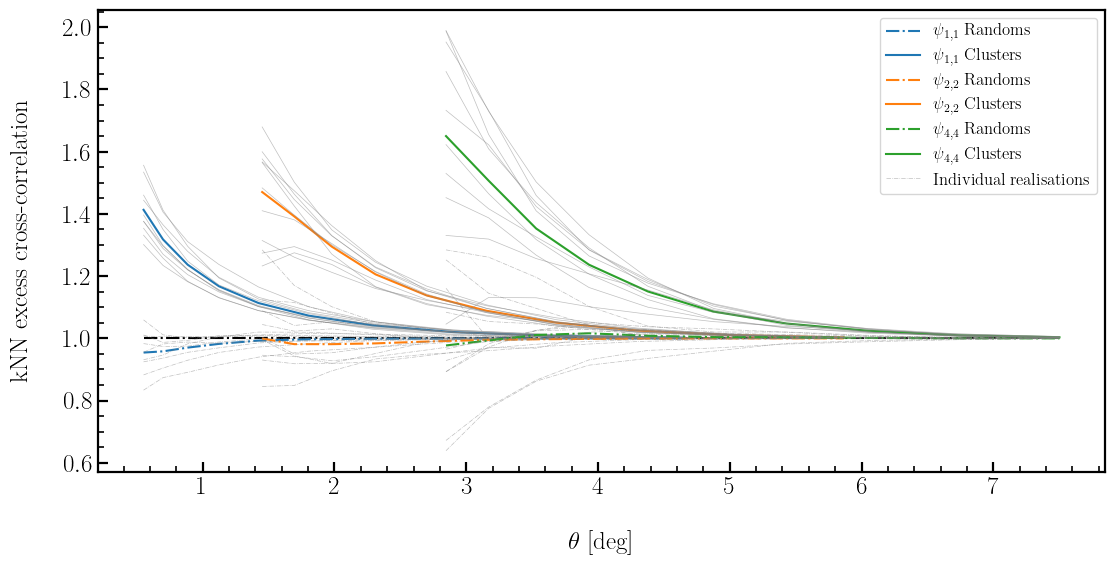

In [35]:
plt.figure(figsize=(13, 6))

x_plots = np.linspace(sel_bins[0][0], sel_bins[-1][-1], 100)
plt.plot(np.rad2deg(x_plots), np.ones_like(x_plots), 'k-.', label=None)

for i, k in enumerate(k_List):
    
    plt.plot(np.rad2deg(sel_bins[i]), np.mean(psi[i][:n_reals], axis=0), c=DefaultColorCycle[i], ls='-.', label='$\\psi_{{{:.0f}, {:.0f}}}$ Randoms'.format(k, k))
    for realisation in range(1, n_reals):
        plt.plot(np.rad2deg(sel_bins[i]), psi[i][:n_reals][realisation], c='grey', ls='-.', lw=0.5, alpha=0.5, label=None)

    plt.plot(np.rad2deg(sel_bins[i]), np.mean(psi[i][n_reals:], axis=0), c=DefaultColorCycle[i], label='$\\psi_{{{:.0f}, {:.0f}}}$ Clusters'.format(k, k))
    for realisation in range(n_reals):
        plt.plot(np.rad2deg(sel_bins[i]), psi[i][n_reals:][realisation], c='grey', lw=0.5, alpha=0.5, label=None)

plt.plot(np.rad2deg(sel_bins[i]), psi[i][:n_reals][0], c='grey', ls='-.', lw=0.5, alpha=0.5, label='Individual realisations')
        
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('kNN excess cross-correlation\n')
plt.legend(fontsize=12)
plt.show()
plt.close()

#### We can clearly see a strong separation between the clusters and the randoms, even taking into account the spread across the realisations, demonstrating the detection of a robust clustering signal. Further note how the average across the randoms is very close to 1, as expected for a sample that is uncorrelated with the galaxies. This serves as a sanity check for our analysis.

#### <a name="think_ch" id="think_ch"></a> Thinking challenge

The number of galaxy-scale haloes in any given cosmological volume is far greater than the number of cluster-scale haloes. For example, in the Quijote box we are exploring, there are only about 9000 cluster-scale haloes, but more than 600,000 galaxy-scale haloes. However, we need the number densities to be similar in order to measure cross-correlations using the nearest neighbour distributions. This means that we have to down-sample the galaxy-scale halo samply by a factor of $\sim100$. This downsampling can lead to an additional source of noise in the measurements, and may even result in a bias if the downsampled haloes are not representative of the population. Can you think of a way to solve this issue? Hint: think about approaches to determine population-level properties using size-limited samples.

#### <a name="comp_ch" id="comp_ch"></a> Computational challenge

Try to implement the solution to the above thinking challenge using the computational methods you have learned in this tutorial notebook. How do the updated measurements differ from the original ones we computed? Are there improvements in the signal-to-noise, and if so, what is the trade-off? (hint: think about computational efficiency of the different approaches.) How would you decide which approach to follow?

In [34]:
#Type your solution below

#### <a name="comp_ch_1" id="comp_ch_1"></a> Another computational challenge

In the main example presented above, we computed cross-correlations using the same order nearest neighbours for the mock clusters and galaxies. An alternate solution to the problem of correlating tracers with different densities is to use nearest neighbours of different orders. This is because different nearest neighbour orders are sensitive to different number densities at the same distance scales, with larger orders sensitive to larger densities (see [Banerjee & Abel (2021)](https://academic.oup.com/mnras/article/504/2/2911/6246418?login=false) for a discussion).

1. What order nearest neighbour distribution should be used to cross correlate 10,000 galaxies with the first-nearest neigbour distribution of 2,000 clusters?
2. Compute the above cross-correlation.
3. How does this approach compare to the one we followed in challenge 1, both in terms of signal-to-noise and computational cost?

In [34]:
#Type your solution below